# 00 — Extracción y exploración — LockBit Panel DB

Parsea `paneldb_dump.sql` (volcado MySQL del panel de administración de LockBit),  
guarda cada tabla como parquet y produce una exploración inicial del dataset.

**A diferencia de ContiLeaks/BlackBasta**, este dataset no son chats entre miembros  
del grupo — es la base de datos operacional del panel: víctimas, operadores, builds  
de malware y negociaciones de rescate con las víctimas.

Produce en `data/processed/`:
- `users.parquet`
- `clients.parquet`
- `chats.parquet`
- `builds.parquet`
- `btc_addresses.parquet`
- `invites.parquet`

## 0. Setup

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path('src').resolve()))

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
from loaders import load_lockbit

SQL_ZIP      = Path('/home/drjekyll/Documentos/umbrella/data_bruto/Ransomware/Lockbit_paneldb_dump 2025.zip')
PROCESSED    = Path('../data/processed')
PROCESSED.mkdir(parents=True, exist_ok=True)

assert SQL_ZIP.exists(), f'No se encuentra {SQL_ZIP}'
print(f'Archivo: {SQL_ZIP.name}  ({SQL_ZIP.stat().st_size/1024**2:.1f} MB)')

Archivo: Lockbit_paneldb_dump 2025.zip  (7.1 MB)


## 1. Carga y extracción

In [2]:
print('Parseando SQL dump (dos pasadas: schema + datos)...')
tables = load_lockbit(SQL_ZIP)

print('\n=== TABLAS EXTRAÍDAS ===')
for name, df in sorted(tables.items()):
    print(f'  {name:20s}: {len(df):6,} filas x {len(df.columns):2d} cols')

Parseando SQL dump (dos pasadas: schema + datos)...

=== TABLAS EXTRAÍDAS ===
  btc_addresses       : 59,975 filas x  5 cols
  builds              :  1,183 filas x 18 cols
  chats               :  4,423 filas x 15 cols
  clients             :    246 filas x 26 cols
  invites             :  3,693 filas x  8 cols
  pkeys               : 30,000 filas x  8 cols
  users               :     75 filas x 28 cols


In [3]:
# Guardar como parquet (excluimos pkeys por tamaño y sensibilidad)
SAVE_TABLES = ['users', 'clients', 'chats', 'builds', 'btc_addresses', 'invites']

for name in SAVE_TABLES:
    out = PROCESSED / f'{name}.parquet'
    tables[name].to_parquet(out, index=False)
    print(f'  {out.name}  ({out.stat().st_size/1024:.0f} KB)')

print('\nParquets guardados.')

  users.parquet  (29 KB)
  clients.parquet  (32 KB)
  chats.parquet  (345 KB)
  builds.parquet  (985 KB)
  btc_addresses.parquet  (2753 KB)
  invites.parquet  (450 KB)

Parquets guardados.


## 2. Operadores / Afiliados

In [4]:
users = tables['users']

print('=== OPERADORES Y AFILIADOS ===')
print(f'Total registrados : {len(users)}')
print(f'Administradores   : {(users.is_admin == 1).sum()}')
print(f'Nivel 4 (admin)   : {(users.level == 4).sum()}')
print(f'Con tag "newbie"  : {(users.tag == "newbie").sum()}')
print(f'Con tag "verified": {(users.tag == "verified").sum()}')
print()
print('Primeros 15 usuarios (login, nivel, tag, último acceso):')
display(users[['id','login','is_admin','level','tag','last_online_dt']].head(15))

=== OPERADORES Y AFILIADOS ===
Total registrados : 75
Administradores   : 1
Nivel 4 (admin)   : 1
Con tag "newbie"  : 62
Con tag "verified": 5

Primeros 15 usuarios (login, nivel, tag, último acceso):


,id,login,is_admin,level,tag,last_online_dt
0,1,admin,1,4,,2025-04-29 12:46:02+00:00
1,2,matrix777,0,1,,2025-04-29 11:29:42+00:00
2,3,fedor,0,1,newbie,2024-12-19 00:10:02+00:00
3,4,KeaynBaker,0,1,newbie,2024-12-19 01:20:25+00:00
4,5,five,0,1,newbie,2024-12-20 14:57:05+00:00
5,6,OranBarnes,0,1,newbie,2025-01-31 13:44:07+00:00
6,7,BroganAlbert,0,1,newbie,2024-12-19 00:33:22+00:00
7,8,FezaanBlanchard,0,1,newbie,2024-12-19 00:34:39+00:00
8,9,ArdalBlankenship,0,1,newbie,2025-02-14 20:25:14+00:00
9,10,Brown,0,1,verified,2025-04-03 13:40:39+00:00


## 3. Víctimas (clients)

In [5]:
clients = tables['clients']

print('=== VÍCTIMAS ===')
print(f'Total víctimas         : {len(clients)}')
print(f'Con actividad de chat  : {clients.id.isin(tables["chats"].clientid).sum()}')
print(f'Pagaron comisión       : {(clients.paid_commission == 1).sum()}')
print(f'Descifrado completado  : {(clients.decrypt_done > 0).sum()}')
print(f'Baneadas               : {(clients.banned == 1).sum()}')
print()

# Operadores con más víctimas asignadas
op_victims = clients.groupby('advid').size().sort_values(ascending=False)
print('Top 10 operadores por víctimas asignadas (advid):')
print(op_victims.head(10).to_string())

=== VÍCTIMAS ===
Total víctimas         : 246
Con actividad de chat  : 208
Pagaron comisión       : 7
Descifrado completado  : 0
Baneadas               : 22

Top 10 operadores por víctimas asignadas (advid):
advid
25    44
18    42
12    19
70    17
43    17
65    12
28    10
21     7
15     7
55     6


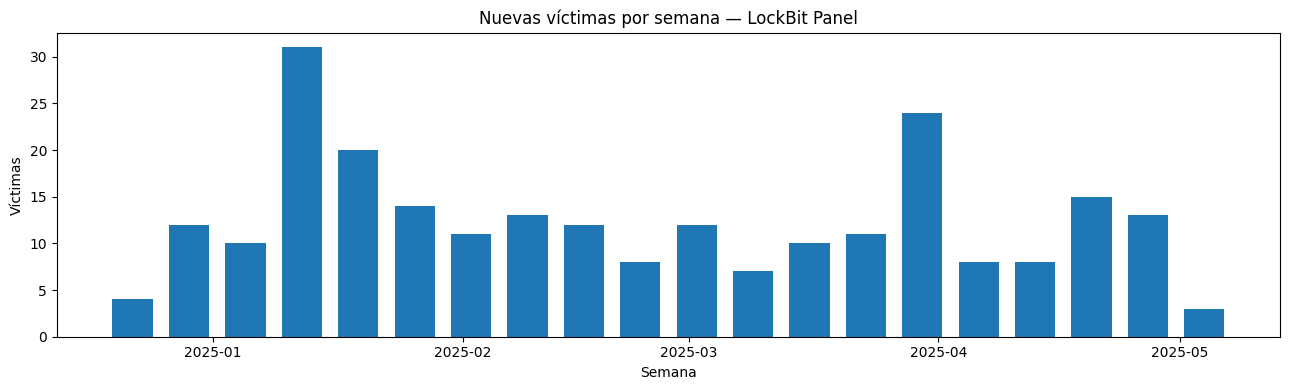

Pico: 2025-01-12  (31 víctimas/semana)
Rango temporal: 2024-12-19 → 2025-04-29


In [6]:
# Timeline de compromisos
clients_valid = clients.dropna(subset=['date_first'])
weekly = clients_valid.set_index('date_first').resample('W').size()

fig, ax = plt.subplots(figsize=(13, 4))
ax.bar(weekly.index, weekly.values, width=5)
ax.set_title('Nuevas víctimas por semana — LockBit Panel')
ax.set_xlabel('Semana')
ax.set_ylabel('Víctimas')
plt.tight_layout()
plt.show()

print(f'Pico: {weekly.idxmax().date()}  ({weekly.max()} víctimas/semana)')
print(f'Rango temporal: {clients_valid.date_first.min().date()} → {clients_valid.date_first.max().date()}')

## 4. Builds de malware

In [7]:
builds = tables['builds']

print('=== BUILDS ===')
print(f'Total builds           : {len(builds)}')
print(f'Operadores distintos   : {builds.userid.nunique()}')
print()
print('Distribución por tipo:')
print(builds.type.value_counts().to_string())
print()
print('Distribución por revenue range:')
if 'revenue' in builds.columns:
    print(builds.revenue.value_counts().head(10).to_string())

=== BUILDS ===
Total builds           : 1183
Operadores distintos   : 54

Distribución por tipo:
type
30    504
25    297
46    151
40    143
50     88

Distribución por revenue range:
revenue
5kk     243
10kk    203
10k     199
1kk      66
100k     51
15kk     35
4kk      31
20k      24
15k      22
20kk     15


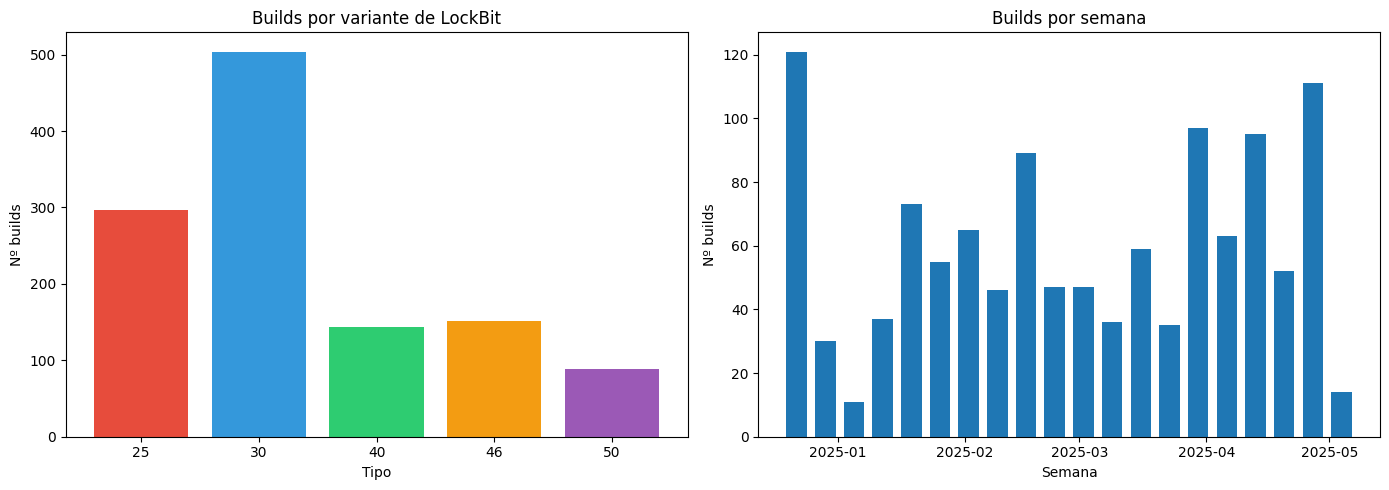

In [8]:
# Evolución temporal de builds
builds_valid = builds.dropna(subset=['date'])
builds_weekly = builds_valid.set_index('date').resample('W').size()

# Builds por tipo
type_colors = {25: '#e74c3c', 30: '#3498db', 40: '#2ecc71', 46: '#f39c12', 50: '#9b59b6'}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Izq: distribución de tipos
type_counts = builds.type.value_counts().sort_index()
colors = [type_colors.get(t, '#95a5a6') for t in type_counts.index]
axes[0].bar([str(t) for t in type_counts.index], type_counts.values, color=colors)
axes[0].set_title('Builds por variante de LockBit')
axes[0].set_xlabel('Tipo')
axes[0].set_ylabel('Nº builds')

# Der: timeline
axes[1].bar(builds_weekly.index, builds_weekly.values, width=5)
axes[1].set_title('Builds por semana')
axes[1].set_xlabel('Semana')
axes[1].set_ylabel('Nº builds')

plt.tight_layout()
plt.show()

## 5. Chats de negociación (vista previa)

In [9]:
chats = tables['chats']

print('=== CHATS DE NEGOCIACIÓN ===')
print(f'Total mensajes       : {len(chats):,}')
print(f'Víctimas distintas   : {chats.clientid.nunique()}')
print(f'Operadores distintos : {chats.advid.nunique()}')
print(f'Mensajes operador    : {(chats.flag==1).sum():,}')
print(f'Mensajes víctima     : {(chats.flag==0).sum():,}')
print(f'Con adjuntos         : {(chats.is_file==1).sum()}')
print(f'Rango                : {chats.created_at.min().date()} → {chats.created_at.max().date()}')
print()
print('Ejemplo de negociación (victim 24):')
sample = chats[chats.clientid == chats.clientid.iloc[0]].sort_values('created_at')
for _, row in sample.head(6).iterrows():
    sender = 'OPERADOR' if row.flag == 1 else 'VÍCTIMA '
    msg = str(row.content)[:100].replace('\n', ' ') if row.content else '[adjunto]'
    print(f"  [{row.created_at.strftime('%H:%M')}] {sender}: {msg}")

=== CHATS DE NEGOCIACIÓN ===
Total mensajes       : 4,423
Víctimas distintas   : 208
Operadores distintos : 35
Mensajes operador    : 2,217
Mensajes víctima     : 2,206
Con adjuntos         : 188
Rango                : 2024-12-19 → 2025-04-29

Ejemplo de negociación (victim 24):
  [04:45] VÍCTIMA : You can attach a few files for test decryption by packing them into an archive with zip, rar, tar, 7
  [05:35] VÍCTIMA : [adjunto]
  [05:40] VÍCTIMA : how much decrypt file 
  [05:41] OPERADOR: 4000$ we accept bitcoin only
  [05:42] OPERADOR: realchristmasglobe.zip not a correct file send again
  [05:42] OPERADOR: cant open it


## 6. Invites (estructura de reclutamiento)

In [10]:
invites = tables['invites']

print('=== INVITES / AFILIACIÓN ===')
print(f'Total invites    : {len(invites)}')
print(f'Aceptadas (50)   : {(invites.status == 50).sum()}')
print(f'Pendientes (0)   : {(invites.status == 0).sum()}')
print(f'Con wallet BTC   : {invites.btc_wallet.notna().sum()}')
print(f'Con wallet XMR   : {invites.monero_wallet.notna().sum()}')

amounts = pd.to_numeric(invites.amount, errors='coerce').dropna()
if len(amounts) > 0:
    print(f'\nMontos de afiliación (BTC/XMR):')
    print(f'  Mín: {amounts.min():.6f}')
    print(f'  Máx: {amounts.max():.6f}')
    print(f'  Mediana: {amounts.median():.6f}')

=== INVITES / AFILIACIÓN ===
Total invites    : 3693
Aceptadas (50)   : 72
Pendientes (0)   : 3449
Con wallet BTC   : 2338
Con wallet XMR   : 1355

Montos de afiliación (BTC/XMR):
  Mín: 0.007172
  Máx: 4.610729
  Mediana: 0.009185


## 7. Resumen final del dataset

In [11]:
print('╔══════════════════════════════════════════════╗')
print('║          RESUMEN — LOCKBIT PANEL DB          ║')
print('╠══════════════════════════════════════════════╣')
print(f'║  Operadores registrados : {len(users):>6,}           ║')
print(f'║  Víctimas comprometidas : {len(clients):>6,}           ║')
print(f'║  Víctimas que pagaron   : {(clients.paid_commission==1).sum():>6,}           ║')
print(f'║  Tasa de conversión     :  {(clients.paid_commission==1).sum()/len(clients)*100:>5.1f}%           ║')
print(f'║  Builds de malware      : {len(builds):>6,}           ║')
print(f'║  Mensajes de negociación: {len(chats):>6,}           ║')
print(f'║  Invites de afiliación  : {len(invites):>6,}           ║')
print(f'║  Direcciones Bitcoin    : {len(tables["btc_addresses"]):>6,}           ║')
print(f'║  Período cubierto       : dic 2024 – abr 2025   ║')
print('╚══════════════════════════════════════════════╝')

╔══════════════════════════════════════════════╗
║          RESUMEN — LOCKBIT PANEL DB          ║
╠══════════════════════════════════════════════╣
║  Operadores registrados :     75           ║
║  Víctimas comprometidas :    246           ║
║  Víctimas que pagaron   :      7           ║
║  Tasa de conversión     :    2.8%           ║
║  Builds de malware      :  1,183           ║
║  Mensajes de negociación:  4,423           ║
║  Invites de afiliación  :  3,693           ║
║  Direcciones Bitcoin    : 59,975           ║
║  Período cubierto       : dic 2024 – abr 2025   ║
╚══════════════════════════════════════════════╝
